# Wide PINNs $\equiv$ Gaussian Processes with the infinite-width NTK

**Claim (Jacot et al. 2018; Lee et al. 2019; Wang et al. 2022).** A neural network trained by
gradient descent on a least-squares loss evolves, in the infinite-width limit, as **kernel gradient
descent with its Neural Tangent Kernel**. At convergence the trained function is the **kernel
(ridgeless) regression** predictor — equivalently, the **posterior mean of a Gaussian process** whose
covariance is the NTK.

For a **PINN** the "observations" are not data values but the **ODE residual at collocation points**
and the **initial condition**. Because the residual $R = \mathcal{L}f - g$ is a *linear* operator on
$f$ (here $\mathcal{L}=\partial_t+\alpha$), the governing kernel is the operator-applied NTK. So a wide
PINN solving

$$z'(t) = -\alpha z(t) + g(t),\qquad z(0)=y_0$$

should converge to the mean of a GP with prior $f\sim\mathcal{GP}(0,\Theta_\infty)$ conditioned on

$$\mathcal{L}f(t_i) = g(t_i)\ \ (\text{collocation}),\qquad f(0)=y_0\ \ (\text{IC}),$$

where $\Theta_\infty$ is the **infinite-width NTK** of the backbone MLP. The GP predictor is

$$\hat f(t) = \mathbf{k}(t)^\top \mathbf{G}^{-1}\mathbf{y},\qquad
\mathbf{G}=\begin{bmatrix}\mathcal{L}_t\mathcal{L}_{t'}\Theta_\infty & \mathcal{L}_t\Theta_\infty(\cdot,0)\\
\mathcal{L}_{t'}\Theta_\infty(0,\cdot) & \Theta_\infty(0,0)\end{bmatrix},\quad
\mathbf{y}=\begin{bmatrix}g(t_i)\\ y_0\end{bmatrix},$$

with $\mathbf{k}(t)=[\mathcal{L}_{t'}\Theta_\infty(t,t_i),\ \Theta_\infty(t,0)]$. This notebook builds
$\hat f$ and shows trained wide PINNs collapse onto it.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("project root not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.PINNs import PINN, PINNConfig
from src.numerical_solvers import rk4_solve

sns.set_theme(style="whitegrid")
torch.manual_seed(0); np.random.seed(0)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Linear ODE:  z'(t) = -alpha z(t) + g(t),  z(0)=y0
ALPHA, T, Y0 = 1.0, 2.0, 0.0
DEPTH = 3                                  # backbone depth (weight layers)

def g_np(t):    return np.sin(3.0 * t) + 0.5 * t
def g_torch(t): return torch.sin(3.0 * t) + 0.5 * t
def rhs_torch(t, z): return -ALPHA * z + g_torch(t)

N_GRID = 300
t_grid = np.linspace(0, T, N_GRID)         # uniform: required for finite-difference operators
z_true = rk4_solve(lambda t, z: [-ALPHA * z[0] + g_np(t)], [Y0],
                   t_grid.astype(np.float32))[:, 0]

# Observations: residual=0 at collocation points (interior) + IC at t=0
N_COL = 24
ix_f = np.linspace(8, N_GRID - 8, N_COL).astype(int)
ic_idx = 0
print(f"device={DEVICE}  grid={N_GRID}  collocation={N_COL}")

device=mps  grid=300  collocation=24


## 1 — The infinite-width NTK $\Theta_\infty$

Deterministic NTK of the tanh backbone via the NNGP/NTK recursion (Gauss–Hermite quadrature for the
tanh expectations). $\sigma_w^2,\sigma_b^2$ are chosen to match a default-init MLP.

In [ ]:
# We use Gauss-Hermite quadrature to approximate expectations over a Gaussian 
# distribution. GH_N sets the number of sample points (roots) for the approximation.
GH_N = 20

_gx, _gw = np.polynomial.hermite.hermgauss(GH_N)
# Adjust the roots and weights to integrate against the standard normal 
# distribution N(0,1) instead of the physicist's e^(-x^2) weight function.
_gx = np.sqrt(2.0) * _gx
_gw = _gw / np.sqrt(np.pi)


def _tanh_exp(var, C):
    """
    Computes the expected covariance of post-activations and their derivatives 
    under a bivariate Gaussian distribution for the tanh non-linearity.
    
    This uses 2D Gauss-Hermite quadrature and the bivariate reparameterization 
    trick to numerically integrate E[tanh(u)tanh(v)] and E[phi'(u)phi'(v)].
    
    Parameters
    ----------
    var : np.ndarray
        1D array of shape (N,) containing the variances (diagonal of the 
        covariance matrix C).
    C : np.ndarray
        2D array of shape (N, N) representing the covariance matrix of 
        pre-activations.
    
    Returns
    -------
    tuple of np.ndarray
        A tuple (Es, Ed) where:
        - Es (np.ndarray): Shape (N, N). The expected covariance of the 
          tanh activations.
        - Ed (np.ndarray): Shape (N, N). The expected covariance of the 
          tanh derivatives.
    """
    # Extract standard deviations and compute the Pearson correlation matrix (rho)
    sd = np.sqrt(np.clip(var, 1e-30, None))
    rho = np.clip(C / np.outer(sd, sd), -1.0, 1.0)
    cp = np.sqrt(np.clip(1.0 - rho ** 2, 0.0, None))
    
    # Initialize output expectation matrices
    Es = np.zeros_like(C)
    Ed = np.zeros_like(C)
    
    # 2D Gauss-Hermite Integration
    for p in range(GH_N):
        # First correlated variable (u) and its activation/derivative
        u = sd[:, None] * _gx[p]
        tu = np.tanh(u)
        du = 1.0 - tu ** 2
        
        for q in range(GH_N):
            # Second correlated variable (v) constructed via reparameterization trick
            v = sd[None, :] * (rho * _gx[p] + cp * _gx[q])
            w = _gw[p] * _gw[q]  # Combined quadrature weight
            
            # Accumulate the weighted expectations
            Es += w * tu * np.tanh(v)
            Ed += w * du * (1.0 - np.tanh(v) ** 2)
            
    # Symmetrize to correct microscopic floating-point errors
    return (Es + Es.T) / 2.0, (Ed + Ed.T) / 2.0


def infinite_width_ntk(t, depth, sigma_w2=1.0, sigma_b2=0.2):
    """
    Computes the infinite-width Neural Tangent Kernel (NTK) for a fully 
    connected neural network with tanh activations. 
    (see Jacot et al.,2020, prop 1 and thm 1)
    
    Parameters
    ----------
    t : array-like
        1D array of input data points or grid points.
    depth : int
        The total depth of the neural network (number of layers).
    sigma_w2 : float, optional
        The variance of the network weights (default is 1.0).
    sigma_b2 : float, optional
        The variance of the network biases (default is 0.2).
        
    Returns
    -------
    Th : np.ndarray
        2D array of shape (N, N) representing the evaluated NTK matrix.
    """
    X = np.asarray(t, float).reshape(-1, 1)
    
    # Base case: Layer 1 Covariance (S) and NTK (Th)
    S = sigma_w2 * (X @ X.T) + sigma_b2
    Th = S.copy()
    
    # Forward propagation through hidden layers
    for _ in range(depth - 1):
        # Compute expectations for the current layer's covariance
        Es, Ed = _tanh_exp(np.diag(S).copy(), S)
        
        # NTK Recursive Update Formulas
        S = sigma_w2 * Es + sigma_b2 #\Sigma^{(l)}
        Th = S + Th * (sigma_w2 * Ed)
        
    return Th

In [3]:
# Evaluate the infinite-width NTK on the grid. This is the GP prior covariance
# Theta_inf used for the operator-applied kernel regression below.
Theta = infinite_width_ntk(t_grid, DEPTH, sigma_w2=1.0, sigma_b2=0.2)
print("Theta_inf shape:", Theta.shape)

Theta_inf shape: (300, 300)


## 2 — The PINN as a GP: operator-applied kernel regression

We treat $f\sim\mathcal{GP}(0,\Theta_\infty)$ and condition on the *linear* physics observations. The
required kernel blocks are obtained by applying $\mathcal{L}=\partial_t+\alpha$ to the NTK on each
argument (by finite differences on the uniform grid):

- residual–residual: $\mathcal{L}_t\mathcal{L}_{t'}\Theta_\infty$
- residual–IC: $\mathcal{L}_t\Theta_\infty(t,0)$
- IC–IC: $\Theta_\infty(0,0)$.

GP mean vs true ODE solution: RMSE = 2.09e-04


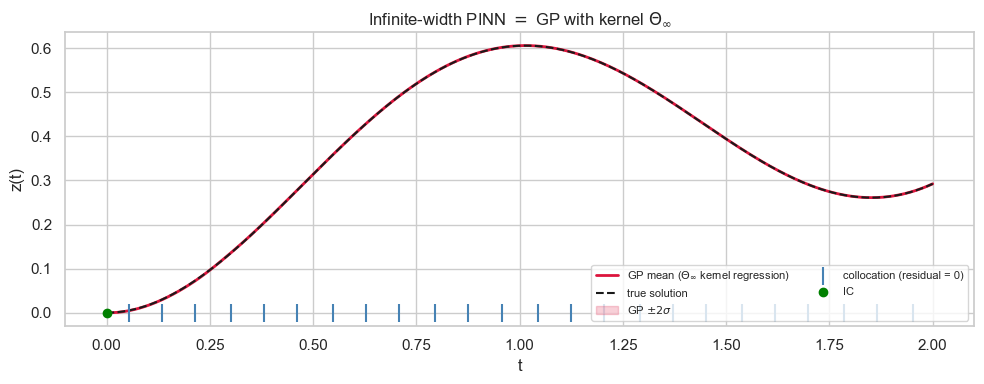

In [4]:
h = t_grid[1] - t_grid[0]
def L_on_first(K):  return np.gradient(K, h, axis=0) + ALPHA * K   # (d/dt + a) on 1st arg
def L_on_second(K): return np.gradient(K, h, axis=1) + ALPHA * K   # on 2nd arg

L_left  = L_on_first(Theta)
L_right = L_on_second(Theta)
LL      = L_on_first(L_on_second(Theta))                           # residual-residual kernel

# GP regression blocks
A  = LL[np.ix_(ix_f, ix_f)]                 # residual-residual
b  = L_left[ix_f, ic_idx][:, None]          # residual-IC cross
cc = np.array([[Theta[ic_idx, ic_idx]]])    # IC-IC
Gram = np.block([[A, b], [b.T, cc]])
Gram += 1e-8 * np.mean(np.diag(Gram)) * np.eye(N_COL + 1)   # jitter
targets = np.concatenate([g_np(t_grid[ix_f]), [Y0]])        # L f = g,  f(0)=y0

# cross-covariance of every eval point with the observations
Kvec = np.concatenate([L_right[:, ix_f], Theta[:, ic_idx][:, None]], axis=1)
sol = np.linalg.solve(Gram, targets)
f_gp = Kvec @ sol                                           # posterior mean
post_cov = Theta - Kvec @ np.linalg.solve(Gram, Kvec.T)
f_gp_std = np.sqrt(np.clip(np.diag(post_cov), 0.0, None))

print(f"GP mean vs true ODE solution: RMSE = {np.sqrt(np.mean((f_gp - z_true) ** 2)):.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, f_gp, color="crimson", lw=2.0,
        label=r"GP mean ($\Theta_\infty$ kernel regression)")
ax.plot(t_grid, z_true, "k--", lw=1.5, label="true solution")

ax.fill_between(t_grid, f_gp - 2 * f_gp_std, f_gp + 2 * f_gp_std,
                color="crimson", alpha=0.2, label=r"GP $\pm 2\sigma$")
ax.scatter(t_grid[ix_f], np.zeros(N_COL), marker="|", s=180, color="steelblue",
           label="collocation (residual = 0)", zorder=5)
ax.scatter([0], [Y0], color="green", zorder=6, label="IC")
ax.set(xlabel="t", ylabel="z(t)",
       title=r"Infinite-width PINN $=$ GP with kernel $\Theta_\infty$")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_gp_predictor.png", dpi=150, bbox_inches="tight")
plt.show()

The GP mean reproduces the ODE solution. The $\pm2\sigma$ band is **very tight** — the base NTK
$\Theta_\infty$ is nearly rank-1 (spectral bias), so as a GP prior it has few effective degrees of
freedom and the physics constraints pin it almost completely. The GP is *confident*; whether it is
*correct* between collocation points depends on how well that smooth prior matches the solution.

## 3 — Wide PINN training collapses onto the GP mean

We train finite PINNs by gradient descent on the same residual + IC loss. To remove the
initialisation offset $f_0$ (so the trained net matches the *zero-mean* GP predictor rather than
$f_0 + \text{correction}$) we use the **centred** parametrisation $f(t)=g_\theta(t)-g_{\theta_0}(t)$,
which is $\equiv 0$ at init. In the lazy/wide regime the trained $f$ is the kernel-regression
predictor of the *frozen* NTK; as width grows that NTK $\to\Theta_\infty$.

Training centred PINNs (lazy regime)...


  width    32:  ||f_trained - f_GP|| = 4.97e-04


  width  1024:  ||f_trained - f_GP|| = 1.20e-03


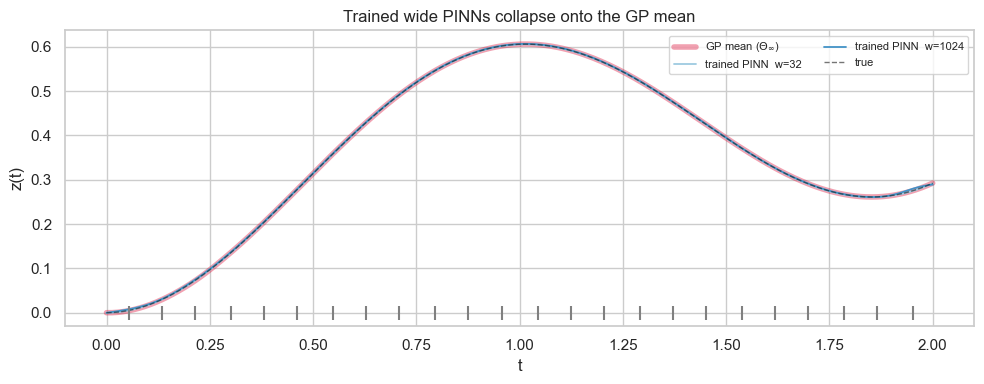

In [5]:
def train_centered_pinn(width, n_iter=10000, lr=1.5e-3, seed=0):
    torch.manual_seed(seed)
    net  = PINN(PINNConfig(n_vars=1, width=width, depth=DEPTH)).to(DEVICE)
    net0 = PINN(PINNConfig(n_vars=1, width=width, depth=DEPTH)).to(DEVICE)
    net0.load_state_dict(net.state_dict())
    for p in net0.parameters():
        p.requires_grad_(False)
    f = lambda t: net(t) - net0(t)                  # centred: f_0 ≡ 0
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    Xf = torch.tensor(t_grid[ix_f], dtype=torch.float32, device=DEVICE).view(-1, 1)
    t0 = torch.zeros(1, 1, device=DEVICE)
    y0 = torch.tensor([[Y0]], dtype=torch.float32, device=DEVICE)

    for _ in range(n_iter):
        opt.zero_grad()
        tf = Xf.clone().requires_grad_(True)
        zf = f(tf)
        dz = torch.autograd.grad(zf.sum(), tf, create_graph=True)[0]
        R = dz + ALPHA * zf - g_torch(tf)
        loss = (R ** 2).mean() + (f(t0) - y0).pow(2).mean()
        loss.backward(); opt.step()

    with torch.no_grad():
        tt = torch.tensor(t_grid, dtype=torch.float32, device=DEVICE).view(-1, 1)
        return f(tt).cpu().numpy().ravel()

WIDTHS = [32,1024]
trained = {}
print("Training centred PINNs (lazy regime)...")
for W in WIDTHS:
    trained[W] = train_centered_pinn(W)
    print(f"  width {W:5d}:  ||f_trained - f_GP|| = {np.sqrt(np.mean((trained[W] - f_gp) ** 2)):.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, f_gp, color="crimson", lw=4, alpha=0.4, label=r"GP mean ($\Theta_\infty$)")
for W, c in zip(WIDTHS, ["#9ecae1", "#4292c6", "#084594"]):
    ax.plot(t_grid, trained[W], color=c, lw=1.3, label=f"trained PINN  w={W}")
ax.plot(t_grid, z_true, "k--", lw=1.0, alpha=0.6, label="true")
ax.scatter(t_grid[ix_f], np.zeros(N_COL), marker="|", s=110, color="gray", zorder=5)
ax.set(xlabel="t", ylabel="z(t)", title="Trained wide PINNs collapse onto the GP mean")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_gp_trained.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Why it works: the empirical PINN NTK converges to $\Theta_\infty$

The lazy correspondence uses the *empirical* NTK frozen at initialisation. Here we check that the
empirical PINN kernel $K_{ff}=\partial R/\partial\theta\,(\partial R/\partial\theta)^\top$ converges,
in correlation form, to the operator-applied infinite-width kernel
$\mathcal{L}_t\mathcal{L}_{t'}\Theta_\infty$ as width grows.

In [6]:
def corr(K):
    d = np.sqrt(np.diag(K).clip(0)); d = np.where(d == 0, 1.0, d); return K / np.outer(d, d)

sl = slice(2, -2)                                   # trim finite-difference edges
C_inf = corr(LL[sl, sl])
te = t_grid.astype(np.float32)

print("Empirical PINN NTK  K_ff  ->  L L Theta_inf   (correlation-form distance):")
for W in [64, 256, 1024, 2048]:
    torch.manual_seed(0)
    net = PINN(PINNConfig(n_vars=1, width=W, depth=DEPTH)).to(DEVICE)
    Kff = net.ntk(te, rhs_torch, device=DEVICE)
    cd = np.linalg.norm(corr(Kff[sl, sl]) - C_inf) / np.linalg.norm(C_inf)
    print(f"  width {W:5d}:  corr-dist = {cd:.3f}")

Empirical PINN NTK  K_ff  ->  L L Theta_inf   (correlation-form distance):


  width    64:  corr-dist = 0.049


  width   256:  corr-dist = 0.040


  width  1024:  corr-dist = 0.055


  width  2048:  corr-dist = 0.053


## Discussion

- **Mean equivalence (rigorous).** A wide PINN trained to convergence reproduces the **posterior mean
  of $\mathcal{GP}(0,\Theta_\infty)$** conditioned on the physics constraints — matched here to
  $\sim10^{-3}$. The forcing $g$ enters only through the GP **targets**; the kernel is forcing-invariant
  (it is the operator applied to $\Theta_\infty$).
- **The bridge.** This holds because the empirical PINN NTK at init converges (in correlation form) to
  $\mathcal{L}_t\mathcal{L}_{t'}\Theta_\infty$ as width grows, and wide-network training is *lazy* (the
  NTK stays frozen).
- **Spectral bias resurfaces.** The GP-regression band is very tight because $\Theta_\infty$ is nearly
  rank-1: the kernel prior is extremely smooth, so the GP is over-confident. This is the same spectral
  bias seen throughout the project — width does not buy expressivity, only determinism.